Setup and Data Loading

In [ ]:
# Setup & Data Loading

from sklearn.preprocessing import StandardScaler
import pandas as pd, numpy as np 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
import tensorflow as tf
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Input, GlobalAveragePooling1D 
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau 
import warnings
warnings.filterwarnings("ignore")

# Load
csv_path =  "Location1.csv"    # Path to the CSV file
df = pd.read_csv(csv_path)
print(f"Loaded {len(df):,} rows from {csv_path}")

# Column  check
required_cols = {
    'Time','temperature_2m','relativehumidity_2m','dewpoint_2m',
    'windspeed_10m','windspeed_100m','Power'
}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing columns in CSV: {sorted(missing)}")

# Parse time robustly and index
df['Time'] = pd.to_datetime(df['Time'], errors='coerce', dayfirst=False, infer_datetime_format=True)
bad = df['Time'].isna().sum()
if bad:
    print(f"Warning: {bad} rows had unparseable Time and were dropped.")
df = df.dropna(subset=['Time']).sort_values('Time').drop_duplicates(subset=['Time'])
df = df.set_index('Time')

# Identify target, select features
df = df.rename(columns={'Power': 'TARGETVAR'})
features = ['temperature_2m','relativehumidity_2m','dewpoint_2m','windspeed_10m','windspeed_100m']
target = 'TARGETVAR'

# Interpolate timewise (fills gaps if the index is a DateTimeIndex)
df[features + [target]] = (
    df[features + [target]]
    .astype(float)
    .interpolate(method='time')
    .ffill()
    .bfill()
)



# Time-based split (80/20 by default). Adjust if you have a known cut date.
split_i = int(len(df) * 0.8)
train_df = df.iloc[:split_i].copy()
test_df  = df.iloc[split_i:].copy()
print(f"Train rows: {len(train_df):,} | Test rows: {len(test_df):,}")

# Fit scalers on TRAIN ONLY (no leakage), transform both
x_scaler = StandardScaler().fit(train_df[features])
y_scaler = StandardScaler().fit(train_df[[target]])

train_X_scaled = x_scaler.transform(train_df[features])
train_y_scaled = y_scaler.transform(train_df[[target]])[:, 0]

test_X_scaled  = x_scaler.transform(test_df[features])
test_y_scaled  = y_scaler.transform(test_df[[target]])[:, 0]

# Include past TARGETVAR as an input feature for next-step prediction
train_in_scaled = np.hstack([train_X_scaled, train_y_scaled.reshape(-1,1)])
test_in_scaled  = np.hstack([test_X_scaled,  test_y_scaled.reshape(-1,1)])
in_feature_names = features + [target]
print(f"Input feature order: {in_feature_names}")

# Sequence maker for next-step forecasting (predict t given t-1...t-24)
def create_sequences(data_2d, y_1d, timesteps):
    X, y = [], []
    for i in range(len(data_2d) - timesteps):
        X.append(data_2d[i:i+timesteps, :])   # (timesteps, n_features)
        y.append(y_1d[i + timesteps])         # predict the step right after the window
    return np.array(X), np.array(y)

timesteps = 24
X_train, y_train = create_sequences(train_in_scaled, train_y_scaled, timesteps)
X_test,  y_test  = create_sequences(test_in_scaled,  test_y_scaled,  timesteps)
print(f"Training shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Testing  shapes: X={X_test.shape},  y={y_test.shape}")


Loaded 43,800 rows from C:\Users\khirh\Desktop\Location1.csv
Train rows: 35,040 | Test rows: 8,760
Input feature order: ['temperature_2m', 'relativehumidity_2m', 'dewpoint_2m', 'windspeed_10m', 'windspeed_100m', 'TARGETVAR']
Training shapes: X=(35016, 24, 6), y=(35016,)
Testing  shapes: X=(8736, 24, 6),  y=(8736,)


Build the TCN model

In [5]:
model = Sequential([
    Input(shape=(timesteps, len(in_feature_names))),
    Conv1D(64, kernel_size=2, padding='causal', dilation_rate=1, activation='relu'),
    Dropout(0.2),
    Conv1D(64, kernel_size=2, padding='causal', dilation_rate=2, activation='relu'),
    Dropout(0.2),
    Conv1D(64, kernel_size=2, padding='causal', dilation_rate=4, activation='relu'),
    Dropout(0.2),
    # Optional: widen receptive field a bit more
    Conv1D(64, kernel_size=2, padding='causal', dilation_rate=8, activation='relu'),
    Dropout(0.2),

    # TCN heads usually take last timestep; GAP is a decent alternative:
    GlobalAveragePooling1D(),
    Dense(32, activation='relu'),
    Dense(1)  # single-step forecast (scaled)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 24, 64)         │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 24, 64)         │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 24, 64)         │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 24, 64)         │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,713 (108.25 KB)

 Trainable params: 27,713 (108.25 KB)

 Non-trainable params: 0 (0.00 B)

Train the model

In [6]:
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-5)
]
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
985/985 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.1496 - mae: 0.2815 - val_loss: 0.0582 - val_mae: 0.1788 - learning_rate: 0.0010
Epoch 2/200
985/985 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0536 - mae: 0.1787 - val_loss: 0.0470 - val_mae: 0.1661 - learning_rate: 0.0010
Epoch 3/200
985/985 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0395 - mae: 0.1537 - val_loss: 0.0227 - val_mae: 0.1109 - learning_rate: 0.0010
Epoch 4/200
985/985 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0325 - mae: 0.1399 - val_loss: 0.0195 - val_mae: 0.1047 - learning_rate: 0.0010
Epoch 5/200
985/985 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0278 - mae: 0.1292 - val_loss: 0.0150 - val_mae: 0.0932 - learning_rate: 0.0010
Epoch 6/200
985/985 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0247 - mae: 0.1211 - val_loss: 0.0192 - val_mae: 0.1053 - learning_rate: 0.0010
Epoch 7/200
985/985 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0224 - mae: 0.1154 - val_loss: 0.0143 - val_mae: 0.0863 - learning_rate: 0.0010

Prediction and Evaluation


Test MSE (scaled): 0.0046 | Test MAE (scaled): 0.0491

--- TCN Model Performance (original units) ---
MAE  : 0.0140
MSE  : 0.0004
RMSE : 0.0193
R^2  : 0.9958


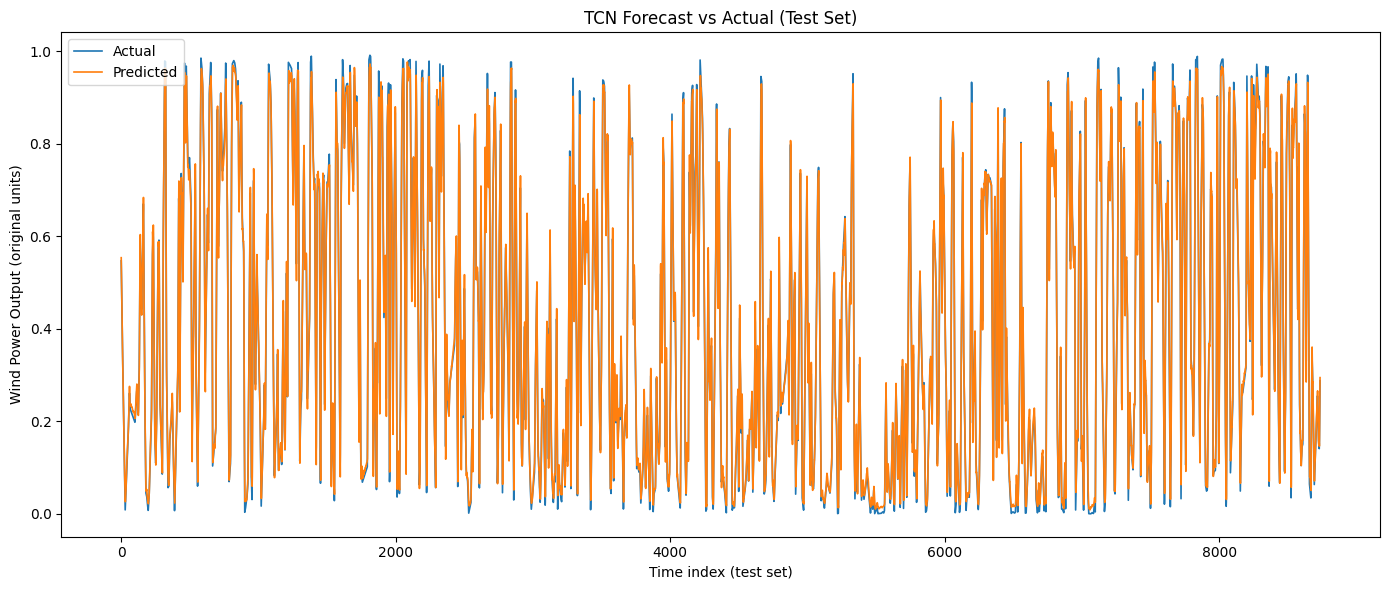

In [8]:
test_mse, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest MSE (scaled): {test_mse:.4f} | Test MAE (scaled): {test_mae:.4f}")

y_pred_scaled = model.predict(X_test, verbose=0).reshape(-1, 1)
y_pred = y_scaler.inverse_transform(y_pred_scaled)[:, 0]
y_true = y_scaler.inverse_transform(y_test.reshape(-1,1))[:, 0]

# Metrics in original units
mae  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_true, y_pred)

print("\n--- TCN Model Performance (original units) ---")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R^2  : {r2:.4f}")


# Plot
plt.figure(figsize=(14,6))
plt.plot(y_true, label='Actual', linewidth=1.2)
plt.plot(y_pred, label='Predicted', linewidth=1.2)
plt.title('TCN Forecast vs Actual (Test Set)')
plt.xlabel('Time index (test set)')
plt.ylabel('Wind Power Output (original units)')
plt.legend()
plt.tight_layout()
plt.show()